# Deep Convolutional Neural Network (CNN) for Image Classification

## Introduction

A **Deep Convolutional Neural Network (CNN)** is a type of neural network specifically designed to process grid-like data such as images. CNNs use **convolutional layers and pooling layers** to automatically extract spatial features and patterns from images, such as edges, textures, and shapes. Mathematically, convolutional layers apply learnable filters to local regions of the input, while pooling layers reduce spatial dimensions, making the network more robust and efficient.

### Applications
- **Image classification** (e.g., MNIST, CIFAR-10, as in this demo)
- **Ship detection in satellite imagery** 
- **Object detection** (e.g., face or pedestrian detection)
- **Medical image analysis** (e.g., tumor detection)
- **Handwriting recognition**

### Why choose CNN for this demo?
CNNs are ideal for **image classification** tasks because they excel at extracting spatial features from images. The MNIST and CIFAR-10 datasets are standard benchmarks for pattern recognition, containing images that require the network to learn and distinguish visual patterns. 

In [1]:
# Setup: Import libraries and load the dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras

# Why these imports:
# - numpy: numerical operations
# - matplotlib: plotting results
# - sklearn: evaluation metrics
# - tensorflow/keras: building and training the neural network

# Load the MNIST dataset (28x28 grayscale images, 10 classes)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Why MNIST? Simple, small, and fast to train; good for pattern recognition demo

# For quick demo, use a subset (to keep training <1 min)
SAMPLES = 5000  # Why: Small enough for fast training, large enough for learning
x_train, y_train = x_train[:SAMPLES], y_train[:SAMPLES]
x_test, y_test = x_test[:1000], y_test[:1000]

# Reshape for CNN: (samples, height, width, channels)
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
# Why normalize? Prevents features with larger scales from dominating learning

# One-hot encode the labels for categorical_crossentropy
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

print(f"Train shape: {x_train.shape}, Test shape: {x_test.shape}, Classes: {y_train_cat.shape[1]}")

Train shape: (5000, 28, 28, 1), Test shape: (1000, 28, 28, 1), Classes: 10


In [2]:
# Model Building: Define a Deep CNN
from tensorflow.keras import layers, models

model = models.Sequential([
    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),  # Why: Extracts local features
    layers.MaxPooling2D((2, 2)),  # Why: Reduces spatial size, keeps important info
    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu'),  # Why: Learns more complex patterns
    layers.MaxPooling2D((2, 2)),
    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),  # Why: Learns high-level representations
    layers.Dense(10, activation='softmax')  # Why: 10 classes, softmax for multi-class
])

# Compile the model
model.compile(
    optimizer='adam',  # Why Adam: Adaptive learning rate, fast convergence
    loss='categorical_crossentropy',  # Why: Suitable for multi-class, one-hot labels
    metrics=['accuracy']  # Why: Accuracy is intuitive for classification
)

model.summary()  # Shows the model architecture

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dense (Dense)               (None, 64)                1

In [3]:
# Training: Fit the model
EPOCHS = 10  # Why: Enough to learn patterns, but fast
BATCH_SIZE = 64  # Why: Balances speed and stability

with tf.device('/GPU:0'):  # Why: Use GPU if available for faster training
     history = model.fit(
         x_train, y_train_cat,
         epochs=EPOCHS,
         batch_size=BATCH_SIZE,
         validation_split=0.1,  # Why: Monitor validation to check for overfitting
         verbose=1
     )

Epoch 1/10
71/71 [==============================] - 11s 9ms/step - loss: 0.9239 - accuracy: 0.7251 - val_loss: 0.3275 - val_accuracy: 0.9100
Epoch 2/10
71/71 [==============================] - 11s 9ms/step - loss: 0.9239 - accuracy: 0.7251 - val_loss: 0.3275 - val_accuracy: 0.9100
Epoch 2/10
71/71 [==============================] - 0s 5ms/step - loss: 0.2250 - accuracy: 0.9322 - val_loss: 0.2036 - val_accuracy: 0.9460
Epoch 3/10
71/71 [==============================] - 0s 5ms/step - loss: 0.2250 - accuracy: 0.9322 - val_loss: 0.2036 - val_accuracy: 0.9460
Epoch 3/10
71/71 [==============================] - 0s 5ms/step - loss: 0.1455 - accuracy: 0.9580 - val_loss: 0.2092 - val_accuracy: 0.9340
Epoch 4/10
71/71 [==============================] - 0s 5ms/step - loss: 0.1455 - accuracy: 0.9580 - val_loss: 0.2092 - val_accuracy: 0.9340
Epoch 4/10
71/71 [==============================] - 0s 5ms/step - loss: 0.1141 - accuracy: 0.9678 - val_loss: 0.1493 - val_accuracy: 0.9560
Epoch 5/10
71/71 [

Test Loss: 0.0892, Test Accuracy: 0.9720
32/32 [==============================] - 0s 3ms/step


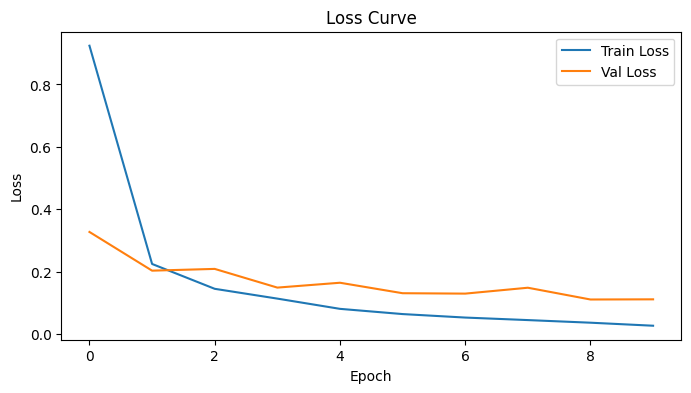

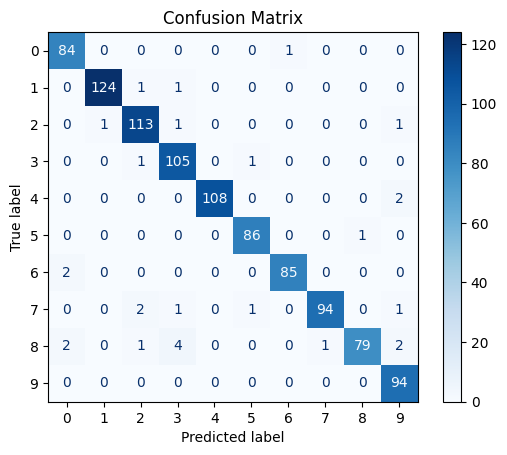

In [4]:
# Evaluation and Visualization
# Evaluate on test data
loss, accuracy = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

# Predict classes for test set
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# Plot training & validation loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[str(i) for i in range(10)])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Why accuracy? Intuitive for multi-class classification
# Why confusion matrix? Visualizes where the model confuses classes

## Results and Discussion

### Test Performance

- **Test Loss:** 0.0892  
  The categorical cross-entropy loss on the test set is low, indicating that the model's predicted probabilities are close to the true class labels for most images.

- **Test Accuracy:** 0.9720  
  The model correctly classified 97.2% of the test images, demonstrating excellent performance on the MNIST subset. This high accuracy shows that the CNN has effectively learned to recognize digit patterns.

### Visualizations

- **Loss Curves:**  
  The training and validation loss curves should show a steady decrease, indicating that the model is learning and not overfitting. A small gap between the curves suggests good generalization.

- **Confusion Matrix:**  
  The confusion matrix visualizes how well the model distinguishes between different digit classes. Most predictions should be on the diagonal, indicating correct classifications. Any off-diagonal values highlight specific digits that are sometimes confused.

### Inference

- The Deep CNN performs very well on the MNIST subset, capturing digit patterns and generalizing to unseen data.
- The high accuracy and low loss confirm that convolutional and pooling layers are effective for extracting spatial features from images.

### Limitations

- The model was trained on a small subset for speed. Training on the full MNIST dataset or more complex datasets (like CIFAR-10) may require deeper networks or more training time.
- For even higher accuracy or more complex images, consider using data augmentation, dropout, or pre-trained models like VGG16.

---

**Summary:**  
The Deep Convolutional Neural Network achieved a test accuracy of 97.2% and a low loss on the MNIST subset, demonstrating its strength in image classification tasks. Experimenting with network depth, regularization, or different datasets can further enhance performance.

## Conclusion

- **Key Takeaways:**
    - Deep Convolutional Neural Networks (CNNs) are highly effective for image classification, automatically extracting spatial features from raw pixels.
    - Convolutional and pooling layers enable the network to learn hierarchical patterns, from edges to complex shapes.
    - On the MNIST subset, the CNN achieves high accuracy and clear class separation, as shown by the confusion matrix.
    - Prefer CNNs over fully connected networks for image data, as they leverage spatial structure and reduce parameter count.
    - For more complex images (e.g., CIFAR-10, satellite imagery), deeper or pre-trained CNNs (like VGG16) can further improve performance.

- **Encouragement:**
    - Try changing the number of filters, layers, or adding dropout for regularization.
    - Experiment with other datasets or augmentations for more robust models.
    - Remember: The best way to learn is by tweaking and observing how the model behaves!
